<a href="https://colab.research.google.com/github/NatNataNaty/INTELIGENCIA_ARTIFICIAL/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from google.colab import drive

# 1. Montar Drive y Leer datos
drive.mount('/content/drive')

# Usamos pandas para el CSV debido a los caracteres especiales de Amazon
path = '/content/drive/MyDrive/Inteligencia Artificial/Laboratorio 1/amazon_sales_dataset.csv'
df = pd.read_csv(path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# --- LIMPIEZA DE DATOS (Para que funcione con Amazon) ---
df.columns = df.columns.str.strip()
# Convertir columnas a números quitando comas y símbolos
cols_num = ['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'discounted_price', 'total_revenue']
for col in cols_num:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('₹', ''), errors='coerce')

# Convertir variables de texto a números para llegar a n >= 10
df['product_id_n'] = df['product_id'].astype('category').cat.codes
df['category_n'] = df['product_category'].astype('category').cat.codes
df['region_n'] = df['customer_region'].astype('category').cat.codes
df['payment_n'] = df['payment_method'].astype('category').cat.codes

df = df.dropna() # Eliminar filas con errores

# Selección de variables (n = 10)
# X incluirá: price, discount_percent, quantity_sold, rating, review_count, total_revenue, product_id_n, category_n, region_n, payment_n
X = df[['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'total_revenue', 'product_id_n', 'category_n', 'region_n', 'payment_n']].values
y = df['discounted_price'].values
m = y.size

print(f"Total de muestras (m): {m}")
display(X[:5])
print(X.shape)

Total de muestras (m): 50000


array([[1.28750e+02, 1.00000e+01, 4.00000e+00, 3.50000e+00, 4.43000e+02,
        4.63520e+02, 1.63700e+03, 1.00000e+00, 3.00000e+00, 3.00000e+00],
       [3.02600e+02, 2.00000e+01, 5.00000e+00, 3.70000e+00, 4.75000e+02,
        1.21040e+03, 1.30000e+03, 3.00000e+00, 0.00000e+00, 1.00000e+00],
       [4.95800e+02, 2.00000e+01, 2.00000e+00, 4.40000e+00, 1.83000e+02,
        7.93280e+02, 2.67000e+03, 5.00000e+00, 1.00000e+00, 3.00000e+00],
       [3.71950e+02, 1.50000e+01, 4.00000e+00, 5.00000e+00, 2.12000e+02,
        1.26464e+03, 1.52200e+03, 1.00000e+00, 2.00000e+00, 3.00000e+00],
       [2.01680e+02, 0.00000e+00, 4.00000e+00, 4.60000e+00, 3.08000e+02,
        8.06720e+02, 7.17000e+02, 0.00000e+00, 2.00000e+00, 3.00000e+00]])

(50000, 10)


In [27]:
# 2. Funciones de Normalización
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división por cero
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

Media calculada: [2.52507260e+02 1.33407000e+01 2.99940000e+00 2.99631600e+00
 2.49329280e+02 6.57331475e+02 1.98684874e+03 2.48838000e+00
 1.50026000e+00 2.01056000e+00]
Desviación estandar calculada: [1.43024114e+02 9.85059508e+00 1.41538675e+00 1.15428334e+00
 1.44250539e+02 5.26218706e+02 1.15636297e+03 1.70905382e+00
 1.11880290e+00 1.41500830e+00]


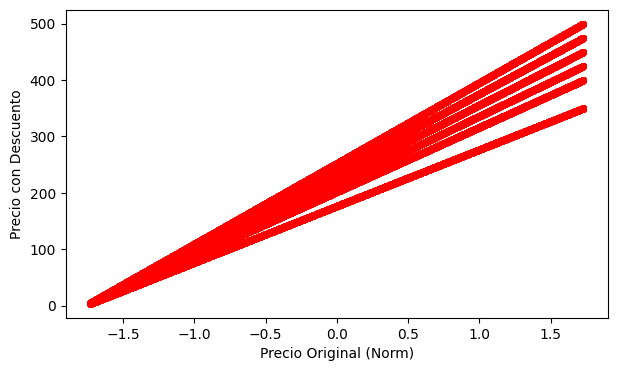

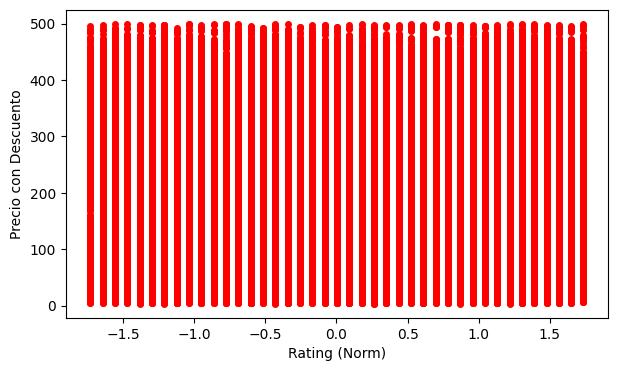

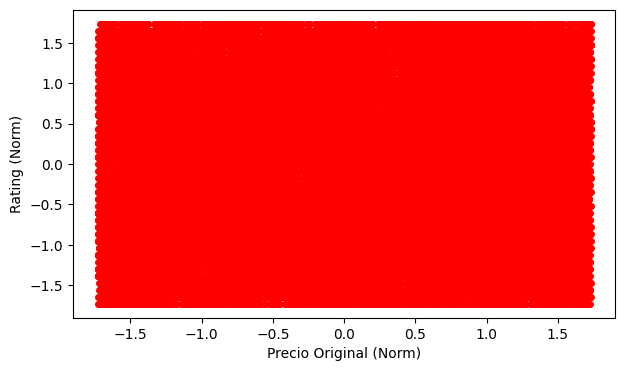

In [28]:
# 3. Gráficos de dispersión iniciales (Como en tu código original)
def graficarDatos(x, y, xlabel, ylabel):
    fig = pyplot.figure(figsize=(7, 4))
    pyplot.plot(x, y, 'ro', ms=4) # 'ro' como pediste
    pyplot.xlabel(xlabel)
    pyplot.ylabel(ylabel)

# Graficamos 3 relaciones importantes como hacías con terreno/calidad
xlabel1 = "Precio Original (Norm)"
xlabel2 = "Rating (Norm)"
ylabel1 = "Precio con Descuento"

graficarDatos(X_norm[:, 0], y, xlabel1, ylabel1)
graficarDatos(X_norm[:, 3], y, xlabel2, ylabel1)
graficarDatos(X_norm[:, 0], X_norm[:, 3], xlabel1, xlabel2)

In [29]:
# 4. Preparación para el Descenso por Gradiente
# Agregar columna de unos
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

def calcularCosto(X, y, theta):
    m = y.size
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

# Probamos con theta inicial (ahora son 11 thetas por las 10 variables + bias)
theta_inicial = np.zeros(11)
JJ = calcularCosto(X_ready, y, theta_inicial)
print(f"Con theta inicial se obtiene un costo de: {JJ}")

def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
    m = y.shape[0]
    theta = theta.copy()
    J_historico = []

    for i in range(numero_iteraciones):
        # Fórmula idéntica a tu código
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_historico.append(calcularCosto(X, y, theta))

    return theta, J_historico

# Parámetros
num_ite = 5000
alpha = 0.01

theta, J_historico = calcularDescensoGradiente(X_ready, y, theta_inicial, alpha, num_ite)
print(f"Los valores de theta calculados son: {theta}")
print(f"Costo final: {J_historico[-1]}")

Con theta inicial se obtiene un costo de: 32060.398207851
Los valores de theta calculados son: [ 2.18886566e+02  1.16323266e+02 -2.31881300e+01 -6.34348027e+00
  1.16195430e-01  5.75823276e-02  1.07098426e+01  1.74402551e-03
  1.73476748e-02 -1.17951931e-02 -7.99608451e-02]
Costo final: 94.02905899723682


Resultado de la predicción: 1384.7709735160472


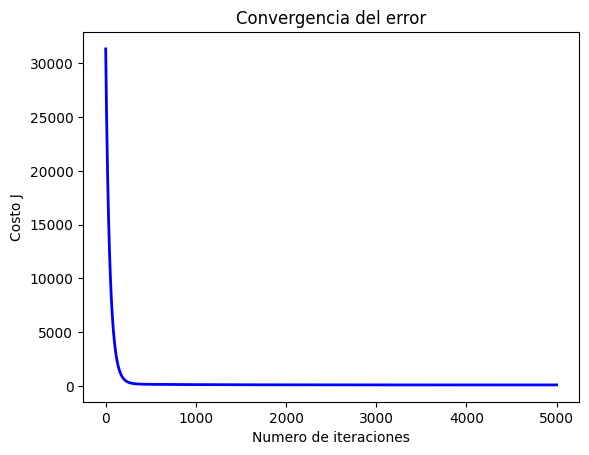

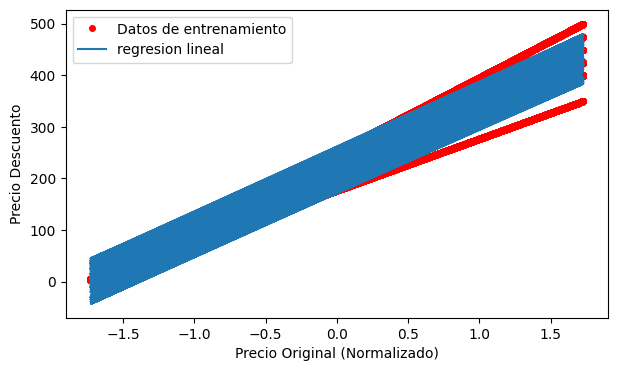

In [30]:
# 5. Gráfico de Convergencia del Costo
pyplot.figure()
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2, color='blue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title("Convergencia del error")

# 6. Gráfico de la Regresión (Línea de ajuste)
graficarDatos(X_ready[:, 1], y, "Precio Original (Normalizado)", "Precio Descuento")
pyplot.plot(X_ready[:, 1], np.dot(X_ready, theta), '-')
pyplot.legend(['Datos de entrenamiento', 'regresion lineal'])

# 7. Predicción (Usando un dato de ejemplo de 10 variables)
# [price, disc_%, qty, rating, reviews, revenue, prod_n, cat_n, reg_n, pay_n]
datos_ejemplo = np.array([1200, 15, 20, 4.2, 500, 24000, 10, 5, 2, 1])
# Normalizar el dato antes de predecir
xp_norm = (datos_ejemplo - mu) / sigma
xp_ready = np.append(1, xp_norm)

y_pred = np.dot(xp_ready, theta)
print(f"Resultado de la predicción: {y_pred}")


In [31]:
# 8. Ecuación de la Normal
def calcularThetaEcuacionNormal(X, y):
    # theta = (X.T * X)^-1 * X.T * y
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

X_ren = np.concatenate([np.ones((m, 1)), X], axis=1)
theta_normal = calcularThetaEcuacionNormal(X_ren, y)

print(f"Thetas calculados (Ecuación Normal): {theta_normal}")

# Predicción con Ecuación Normal (sin normalizar)
X_array = np.append(1, datos_ejemplo)
price_normal = np.dot(X_array, theta_normal)
print(f'Precio predicho (Ecuación Normal): ${price_normal:.2f}')

Thetas calculados (Ecuación Normal): [ 4.27352864e+01  8.21722977e-01 -2.37844502e+00 -3.77160262e+00
  9.97037181e-02  4.17209854e-04  1.73302508e-02 -1.14628689e-06
  1.17923711e-02 -7.49675686e-03 -5.34063853e-02]
Precio predicho (Ecuación Normal): $1334.24
